In [41]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load the dataset
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target column
df["target"] = data.target

# Display the first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [29]:
df.shape

(569, 31)

In [30]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum().sum())

# Check for duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Missing values:
0

Duplicate rows:
0

Features shape: (569, 30)
Target shape: (569,)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (569, 30)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Create the models
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train both models
logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


In [34]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for Logistic Regression
logistic_cv = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

# 5-fold cross-validation for Random Forest
random_forest_cv = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV scores:", logistic_cv)
print("Logistic Regression Mean CV Accuracy:", logistic_cv.mean())

print("\nRandom Forest CV scores:", random_forest_cv)
print("Random Forest Mean CV Accuracy:", random_forest_cv.mean())

Logistic Regression CV scores: [0.96703297 0.97802198 0.96703297 1.         0.98901099]
Logistic Regression Mean CV Accuracy: 0.9802197802197803

Random Forest CV scores: [0.96703297 0.98901099 0.92307692 0.93406593 0.95604396]
Random Forest Mean CV Accuracy: 0.953846153846154


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make predictions
logistic_pred = logistic_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

# Probability predictions for ROC-AUC
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]
random_forest_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate metrics for Logistic Regression
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_pred),
    "Precision": precision_score(y_test, logistic_pred),
    "Recall": recall_score(y_test, logistic_pred),
    "F1-Score": f1_score(y_test, logistic_pred),
    "ROC-AUC": roc_auc_score(y_test, logistic_prob)
}

# Calculate metrics for Random Forest
random_forest_metrics = {
    "Accuracy": accuracy_score(y_test, random_forest_pred),
    "Precision": precision_score(y_test, random_forest_pred),
    "Recall": recall_score(y_test, random_forest_pred),
    "F1-Score": f1_score(y_test, random_forest_pred),
    "ROC-AUC": roc_auc_score(y_test, random_forest_prob)
}

print("LOGISTIC REGRESSION")
for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nRANDOM FOREST")
for metric, value in random_forest_metrics.items():
    print(f"{metric}: {value:.4f}")

LOGISTIC REGRESSION
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-Score: 0.9861
ROC-AUC: 0.9954

RANDOM FOREST
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1-Score: 0.9655
ROC-AUC: 0.9937


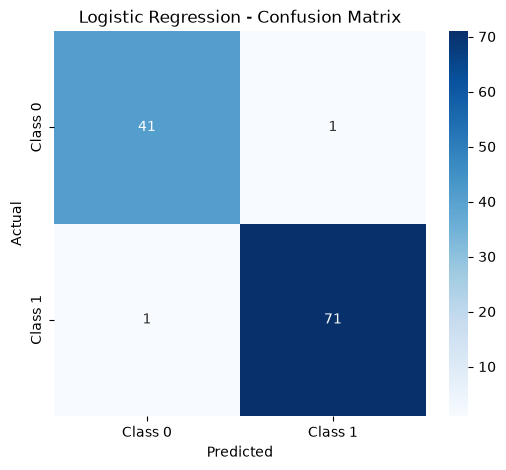

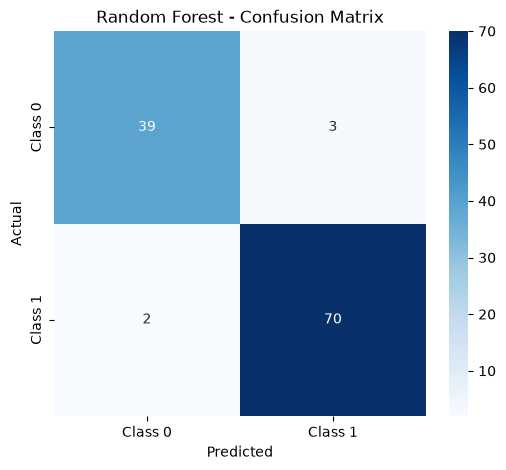

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrices
logistic_cm = confusion_matrix(y_test, logistic_pred)
random_forest_cm = confusion_matrix(y_test, random_forest_pred)

# Logistic Regression confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

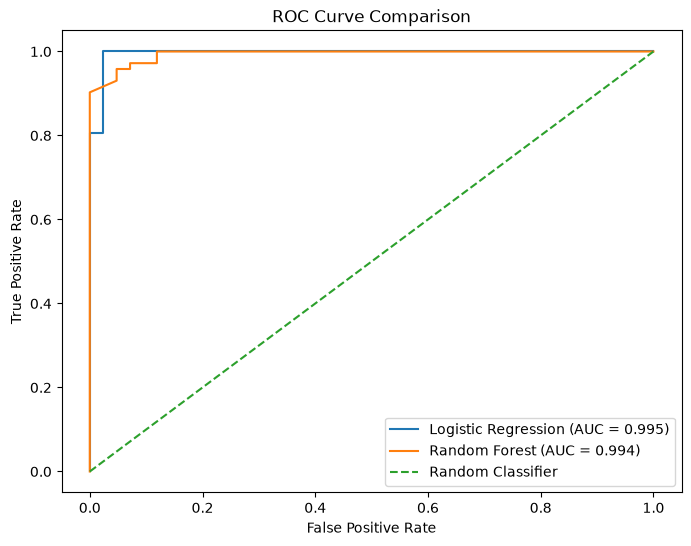

In [37]:
from sklearn.metrics import roc_curve

# Calculate ROC curve values
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_prob)
random_forest_fpr, random_forest_tpr, _ = roc_curve(y_test, random_forest_prob)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    random_forest_fpr,
    random_forest_tpr,
    label=f"Random Forest (AUC = {random_forest_metrics['ROC-AUC']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [38]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        logistic_metrics["Accuracy"],
        logistic_metrics["Precision"],
        logistic_metrics["Recall"],
        logistic_metrics["F1-Score"],
        logistic_metrics["ROC-AUC"]
    ],
    "Random Forest": [
        random_forest_metrics["Accuracy"],
        random_forest_metrics["Precision"],
        random_forest_metrics["Recall"],
        random_forest_metrics["F1-Score"],
        random_forest_metrics["ROC-AUC"]
    ]
})

results

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.982456,0.956140
1,Precision,0.986111,0.958904
2,Recall,0.986111,0.972222
3,F1-Score,0.986111,0.965517
4,ROC-AUC,0.995370,0.993717


In [39]:
# Supervised Classification Model

## Breast Cancer Classification

### Objective
The objective of this project is to build and evaluate supervised classification models using the Breast Cancer Wisconsin dataset.

### Algorithms Used
1. Logistic Regression
2. Random Forest Classifier

### Project Requirements
- Data preprocessing
- Train/test split
- 5-fold cross-validation
- Model comparison
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix
- ROC curve

SyntaxError: invalid syntax (2921808957.py, line 6)

# Supervised Classification Model

## Breast Cancer Classification

### Objective
The objective of this project is to build and evaluate supervised classification models using the Breast Cancer Wisconsin dataset.

### Algorithms Used
1. Logistic Regression
2. Random Forest Classifier

## 1. Dataset

The Breast Cancer Wisconsin dataset is a binary classification dataset.

The dataset contains:
- 569 samples
- 30 input features
- 1 target variable
- 2 target classes

The target variable is used to classify the observations into two classes.

## 1. Dataset

The Breast Cancer Wisconsin dataset is a binary classification dataset.

The dataset contains:
- 569 samples
- 30 input features
- 1 target variable
- 2 target classes

The target variable is used to classify the observations into two classes.

## 2. Data Preprocessing

The dataset was checked for missing values and duplicate rows.

The features were separated from the target variable. StandardScaler was used to standardize the feature values so that the numerical features have a comparable scale.

## 3. Train/Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

The training set was used to train the classification models, while the testing set was used to evaluate their performance.

## 4. Model Training

Two supervised classification algorithms were trained and compared:
1. Logistic Regression
2. Random Forest Classifier

## 5. Cross-Validation

Five-fold cross-validation was performed on both classification models to evaluate their performance across different subsets of the training data.

from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for Logistic Regression
logistic_cv = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

# 5-fold cross-validation for Random Forest
random_forest_cv = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV scores:", logistic_cv)
print("Logistic Regression Mean CV Accuracy:", logistic_cv.mean())

print("\nRandom Forest CV scores:", random_forest_cv)
print("Random Forest Mean CV Accuracy:", random_forest_cv.mean())

In [ ]:
## 6. Model Evaluation

The trained models were evaluated on the test dataset using the following classification metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make predictions
logistic_pred = logistic_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

# Probability predictions for ROC-AUC
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]
random_forest_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate Logistic Regression metrics
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_pred),
    "Precision": precision_score(y_test, logistic_pred),
    "Recall": recall_score(y_test, logistic_pred),
    "F1-Score": f1_score(y_test, logistic_pred),
    "ROC-AUC": roc_auc_score(y_test, logistic_prob)
}

# Calculate Random Forest metrics
random_forest_metrics = {
    "Accuracy": accuracy_score(y_test, random_forest_pred),
    "Precision": precision_score(y_test, random_forest_pred),
    "Recall": recall_score(y_test, random_forest_pred),
    "F1-Score": f1_score(y_test, random_forest_pred),
    "ROC-AUC": roc_auc_score(y_test, random_forest_prob)
}

# Display results
print("LOGISTIC REGRESSION")
for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nRANDOM FOREST")
for metric, value in random_forest_metrics.items():
    print(f"{metric}: {value:.4f}")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make predictions
logistic_pred = logistic_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

# Probability predictions for ROC-AUC
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]
random_forest_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate Logistic Regression metrics
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_pred),
    "Precision": precision_score(y_test, logistic_pred),
    "Recall": recall_score(y_test, logistic_pred),
    "F1-Score": f1_score(y_test, logistic_pred),
    "ROC-AUC": roc_auc_score(y_test, logistic_prob)
}

# Calculate Random Forest metrics
random_forest_metrics = {
    "Accuracy": accuracy_score(y_test, random_forest_pred),
    "Precision": precision_score(y_test, random_forest_pred),
    "Recall": recall_score(y_test, random_forest_pred),
    "F1-Score": f1_score(y_test, random_forest_pred),
    "ROC-AUC": roc_auc_score(y_test, random_forest_prob)
}

# Display results
print("LOGISTIC REGRESSION")
for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nRANDOM FOREST")
for metric, value in random_forest_metrics.items():
    print(f"{metric}: {value:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrices
logistic_cm = confusion_matrix(y_test, logistic_pred)
random_forest_cm = confusion_matrix(y_test, random_forest_pred)

# Logistic Regression
plt.figure(figsize=(6, 5))
sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 7. Confusion Matrices

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Make sure predictions exist
logistic_pred = logistic_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

# Create confusion matrices
logistic_cm = confusion_matrix(y_test, logistic_pred)
random_forest_cm = confusion_matrix(y_test, random_forest_pred)

# Logistic Regression Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 8. ROC Curve

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve values
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_prob)
random_forest_fpr, random_forest_tpr, _ = roc_curve(y_test, random_forest_prob)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    random_forest_fpr,
    random_forest_tpr,
    label=f"Random Forest (AUC = {random_forest_metrics['ROC-AUC']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 9. Model Comparison

In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        logistic_metrics["Accuracy"],
        logistic_metrics["Precision"],
        logistic_metrics["Recall"],
        logistic_metrics["F1-Score"],
        logistic_metrics["ROC-AUC"]
    ],
    "Random Forest": [
        random_forest_metrics["Accuracy"],
        random_forest_metrics["Precision"],
        random_forest_metrics["Recall"],
        random_forest_metrics["F1-Score"],
        random_forest_metrics["ROC-AUC"]
    ]
})

results

## 10. Conclusion

In this project, two supervised classification algorithms, Logistic Regression and Random Forest, were trained and evaluated using the Breast Cancer Wisconsin dataset.

The dataset was preprocessed, standardized, and divided into training and testing sets using an 80:20 split. Five-fold cross-validation was also performed on both models.

The models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Confusion matrices and an ROC curve were used to visualize the model performance.

The model comparison results provide the basis for selecting the more suitable classification model for this dataset.